In [1]:
import matrix
import base
import numpy as np
import matplotlib.pyplot as plt

In [2]:
distances1 = matrix.load_matrix('testmatrix_sym_(1_200)_0.txt')
distances1

array([[  0. ,  86. , 116.5, ...,  58. , 104.5, 167. ],
       [ 86. ,   0. ,  61. , ..., 145. , 131.5, 179.5],
       [116.5,  61. ,   0. , ...,  78. , 184.5, 106. ],
       ...,
       [ 58. , 145. ,  78. , ...,   0. ,  80.5,  82.5],
       [104.5, 131.5, 184.5, ...,  80.5,   0. ,  27.5],
       [167. , 179.5, 106. , ...,  82.5,  27.5,   0. ]])

In [3]:
data = np.genfromtxt('berlin52.tsp',skip_header=6, skip_footer=1, dtype=float)
#data
data.shape

(52, 3)

In [4]:
distancesBerlin = np.zeros((52, 52))
for i in range(52):
    for j in range(52):
        distancesBerlin[i, j] = np.sqrt((data[i, 1] - data[j, 1])**2 + (data[i, 2] - data[i, 2])**2)

#distances2

In [5]:
berlinOptTour = np.loadtxt('berlin52.opt.tour', dtype = int, skiprows = 4, max_rows = 52, )

In [6]:
data2 = np.genfromtxt('pr76.tsp',skip_header=6, skip_footer=1, dtype=float)
pr76OptTour = np.loadtxt('pr76.opt.tour', dtype = int, skiprows = 5, max_rows = 76, )

distancesPR76 = np.zeros((76, 76))
for i in range(76):
    for j in range(76):
        distancesPR76[i, j] = np.sqrt((data2[i, 1] - data2[j, 1])**2 + (data2[i, 2] - data2[i, 2])**2)


In [31]:
def twoPointDist(a, b, distMat):
    return(distMat[a-1][b-1])

def completePathDist_loop(path, distMat):
    N = len(path)
    sum = twoPointDist(path[N-1], path[0], distMat)
    for i in range(N-1):
        #print(sum)
        k = path[i]
        l = path[i+1]
        #print(k, 'to', l)
        sum += twoPointDist(k, l, distMat)
    return(sum)

def MC_constDist_history(points, dist_matrix, tries, starting_temp = 1, alpha = 0.999, method=2):
    
    pathHistory = np.zeros((tries, len(points)))
    pathWeights = np.zeros(tries)
    temps = np.zeros(tries)
    #C = np.zeros(points+1)
    pathWeights[0] = completePathDist_loop(points, dist_matrix)
    temps[0] = starting_temp
    cost = pathWeights[0]
    pathHistory[0] = points

    
    for i in range(tries-1):
        
        new_sequence = base.Opt_method(method,points)
        new_cost = completePathDist_loop(new_sequence, dist_matrix)
        if np.random.uniform(low=0, high=1) < np.exp((pathWeights[i]-new_cost)/temps[i]): 
            points = new_sequence
            cost = new_cost
        pathWeights[i+1] = cost
        pathHistory[i+1] = points
        temps[i+1] = alpha*temps[i]      
    return(pathWeights, pathHistory, temps)

def abbruchCheck(lastRelevantPoint, backInclPoints, array, minChange, minVar):
    a = lastRelevantPoint-backInclPoints
    b = lastRelevantPoint
    arr = array[a:b]
    change = arr[0] - arr[-1]
    var = np.var(arr)

    if (minChange > change & minVar > var):
        return True
    else:
        return False 
    
def travelingMCconstDistbreakConditions(points, dist_matrix, tries, starting_temp = 1, alpha = 0.999, method =2, lastRelevantPoint, backInclPoints, array, minChange, minVar):
    """ input:  points - points that should be visited by each path (in some order) - array
                dist_matrix - matrix containing the 'distances' between each point - 2darray
                tries - itterations of the Monte Carlos - Markov chain - int
                starting_temp - scalar in the exponent of the markov chain acception process - int
                alpha - scalar refgulating the decrease of the temperature after each loop iteration in the MC
                tries_stop - check for ameloration between d[x] and d[x+tries_stop] - int
                ameloration -  Improvement requiered to stop loop
                method - see Opt_method- cuurently random between Lin-2 & Lin-3
        return: points - points that should be visited by each path (in some order) - array
                pathWeights - 'distances' (better weights) of each path - array of int
                temps - temperatures after each MC step - array of int
    """
    
    pathWeights = np.zeros(tries+1)
    temps = np.zeros(tries+1)
    pathWeights[0] = totalTravelDist(points, dist_matrix)
    temps[0] = starting_temp
    cost = pathWeights[0]
    breakCond = False
    for i in range(tries):
    
        new_sequence = Opt_method(method,points)
        new_cost = totalTravelDist(new_sequence, dist_matrix)
        if np.random.uniform(low=0, high=1) < np.exp((pathWeights[i]-new_cost)/temps[i]):
            points = new_sequence
            cost = new_cost
            pathWeights[i+1] = cost
            temps[i+1] = alpha*temps[i] 
        else:
            pathWeights[i+1] = cost
            temps[i+1] = temps[i]
                
    return(points, pathWeights, temps)


In [8]:
testPath = np.arange(1, 53)
#testPath
pointsBerlin = testPath

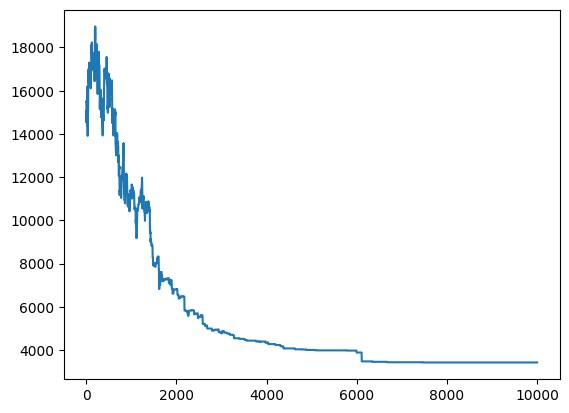

In [10]:
weightHistoryBerlin1, pathHistoryBerlin1, tempsHistoryBerlin1 = MC_constDist_history(pointsBerlin, distancesBerlin, 10000, 500)
plt.plot(np.linspace(1, 10000, 10000), weightHistoryBerlin1)

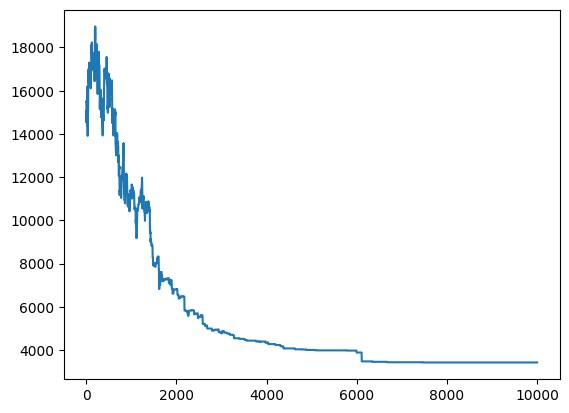

In [11]:
plt.plot(np.linspace(1, 10000, 10000), weightHistoryBerlin1)

In [12]:
minPathWeightBerlin = completePathDist_loop(berlinOptTour, distancesBerlin)
minPathWeightBerlin

np.float64(4590.0)

In [13]:
berlinOptTour

array([ 1, 49, 32, 45, 19, 41,  8,  9, 10, 43, 33, 51, 11, 52, 14, 13, 47,
       26, 27, 28, 12, 25,  4,  6, 15,  5, 24, 48, 38, 37, 40, 39, 36, 35,
       34, 44, 46, 16, 29, 50, 20, 23, 30,  2,  7, 42, 21, 17,  3, 18, 31,
       22])

In [14]:
weightHistoryBerlin1[8000]

np.float64(3430.0)

In [15]:
pathHistoryBerlin1[8000]

array([18., 42.,  7.,  2., 17., 21.,  3., 30., 23., 19., 22.,  1., 10.,
       34., 39., 40., 37., 38., 48.,  6.,  4., 26., 12., 28., 51., 13.,
       14., 11., 52., 27., 47., 33., 25., 43.,  5., 15., 24., 46., 16.,
       44., 36., 35., 29., 49., 50.,  9., 32., 20., 45.,  8., 41., 31.])

In [16]:
completePathDist_loop((pathHistoryBerlin1[8000]).astype(int), distancesBerlin)

np.float64(3430.0)

In [10]:
pointsPR76 = np.arange(1, 77)

/tmp/ipykernel_13527/241491232.py:31: RuntimeWarning: overflow encountered in exp
  if np.random.uniform(low=0, high=1) < np.exp((pathWeights[i]-new_cost)/temps[i]):


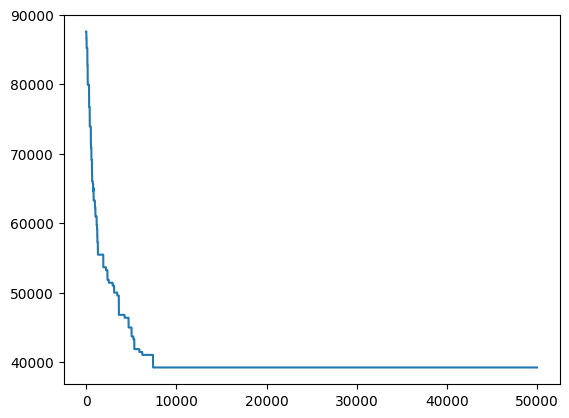

In [11]:
weightHistoryPR76, pathHistoryPR76, tempsHistoryPR76 = MC_constDist_history(pointsPR76, distancesPR76, 50000, 500)
plt.plot(np.linspace(1, 50000, 50000), weightHistoryPR76)

In [12]:
weightHistoryPR76[40000]

np.float64(39200.0)

In [13]:
completePathDist_loop(pr76OptTour, distancesPR76)

np.float64(83672.0)

In [29]:
berlinStarts = np.zeros((5, 52), int)
berlinStarts[0][:] = pointsBerlin
for i in range(5-1):
    arr = berlinStarts[i][:].astype(int)
    #print(berlinStarts[i][:].astype(int))
    for j in range(20):
        arr = (base.Lin_2_Opt(arr)).astype(int)
    berlinStarts[i+1] = arr.astype(int)
berlinStarts[0][0] = int(berlinStarts[0][0])
print(berlinStarts)

[[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
  25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
  49 50 51 52]
 [24 48  9  8  7 52 18 17 20 51 29 42 43 44 45 46 47 10 11 23 22 21  6 38
  25 35 34 14 13 12  1  2 26 36 37  5 28 33 32 31 30 41 40 39 27 50  4  3
  49 15 16 19]
 [ 4 35 34 14 13 12  1  8 23 22 21  6 40 51 29  2 46 47 31 32 33 27 39 20
  44 45  7 52 48  9 11 10 17 15 16 50  3 49 28  5 37 36 26 42 43 24 18 19
  41 30 25 38]
 [38 33 27 39 20 44  4 15 35 26 37 36  5 28 49 16 50  3 10 11  8 23  9 48
  25 30 41 19 18 24  7 52 14 34 13 12 17 22 42 29 51 40  6 21 43 45  2 46
  47 31 32  1]
 [ 2 46 31 32 17 51 40  6 35 22 42 29 27 39 20 14 52  7  3 47  1 13 34 43
  37 23  9  8 11 10 24 18 19 41 49 16 50 45 38 33 26 21 36  5 28 30 25 48
  12 15  4 44]]


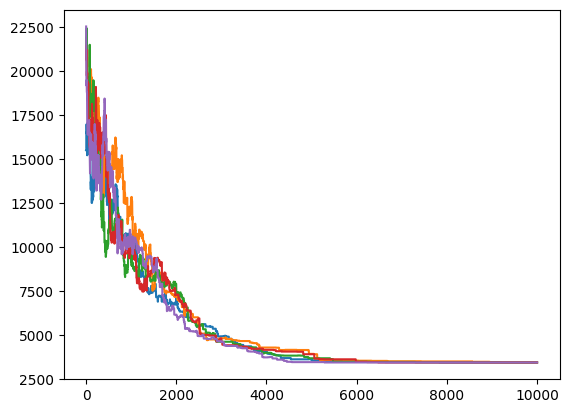

In [30]:
weightHistoryBerlin_binningStart1, pathHistoryBerlin_binningStart1, tempsHistoryBerlin_binningStart1 = MC_constDist_history(berlinStarts[0][:], distancesBerlin, 10000, 500)
plt.plot(np.linspace(1, 10000, 10000), weightHistoryBerlin_binningStart1)

weightHistoryBerlin_binningStart2, pathHistoryBerlin_binningStart2, tempsHistoryBerlin_binningStart2 = MC_constDist_history(berlinStarts[1][:], distancesBerlin, 10000, 500)
plt.plot(np.linspace(1, 10000, 10000), weightHistoryBerlin_binningStart2)
weightHistoryBerlin_binningStart3, pathHistoryBerlin_binningStart3, tempsHistoryBerlin_binningStart3 = MC_constDist_history(berlinStarts[2][:], distancesBerlin, 10000, 500)
plt.plot(np.linspace(1, 10000, 10000), weightHistoryBerlin_binningStart3)
weightHistoryBerlin_binningStart4, pathHistoryBerlin_binningStart4, tempsHistoryBerlin_binningStart4 = MC_constDist_history(berlinStarts[3][:], distancesBerlin, 10000, 500)
plt.plot(np.linspace(1, 10000, 10000), weightHistoryBerlin_binningStart4)
weightHistoryBerlin_binningStart5, pathHistoryBerlin_binningStart5, tempsHistoryBerlin_binningStart5 = MC_constDist_history(berlinStarts[4][:], distancesBerlin, 10000, 500)
plt.plot(np.linspace(1, 10000, 10000), weightHistoryBerlin_binningStart5)